# Exploratory Data Analysis

## 0.0 Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 0.1 Seaborn's Grid Setup & Data Loading

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("../data/processed/vancouver_tech_postings.csv", parse_dates=["First Posting Date"])

In [4]:
print(df.shape)

(4379, 65)


In [5]:
df.head()

,WIC Job Location Snapshot ID,Job Title,Original Job Title,NOC 2016 Code,NOC 2016 Code Name,NOC21 Code,NOC21 Code Name,External Indicator,First Posting Date,Vacancy Count,...,Condition Vision Care,Salary Condition Other Benefits,Commission PER,Commission Type,Hours Per,Hours Minimum,Hours Maximum,Work Hours,Work Hours From Time,Work Hours To Time
0,15538106.0,systems analyst,IT Systems Analyst (ESRI ArcGIS),2171.0,Information systems analysts and consultants,21222.0,Information systems specialists,1,2026-05-11,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN
1,15554305.0,business process analyst,NaN,2171.0,Information systems analysts and consultants,21221.0,Business systems specialists,0,2026-05-15,1,...,No,No,NaN,NaN,Week,40.0,40.0,Yes,09:00,17:00
2,15575608.0,information technology (IT) analyst,Government Relations Specialist,2171.0,Information systems analysts and consultants,21222.0,Information systems specialists,1,2026-05-23,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN
3,15568431.0,devops engineer,Mechatronics Engineer,2173.0,Software engineers and designers,21231.0,Software engineers and designers,1,2026-05-21,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN
4,15538267.0,software engineer,Senior Backend Engineer,2173.0,Software engineers and designers,21231.0,Software engineers and designers,1,2026-05-11,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN


## 0.2 Fixing Code Related Columns (e.g. "WIC Job Location Snapshot ID","NOC 2016 Code", "NOC21 Code")

In [6]:
code_columns = ["WIC Job Location Snapshot ID","NOC 2016 Code", "NOC21 Code"]

In [7]:
for col in code_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

In [8]:
df[code_columns].head()

,WIC Job Location Snapshot ID,NOC 2016 Code,NOC21 Code
0,15538106,2171,21222
1,15554305,2171,21221
2,15575608,2171,21222
3,15568431,2173,21231
4,15538267,2173,21231


## 0.3 Checking  "Fist Posting Date" Data Type 

In [9]:
print(df["First Posting Date"].dtypes)

datetime64[us]


In [10]:
df.head()

,WIC Job Location Snapshot ID,Job Title,Original Job Title,NOC 2016 Code,NOC 2016 Code Name,NOC21 Code,NOC21 Code Name,External Indicator,First Posting Date,Vacancy Count,...,Condition Vision Care,Salary Condition Other Benefits,Commission PER,Commission Type,Hours Per,Hours Minimum,Hours Maximum,Work Hours,Work Hours From Time,Work Hours To Time
0,15538106,systems analyst,IT Systems Analyst (ESRI ArcGIS),2171,Information systems analysts and consultants,21222,Information systems specialists,1,2026-05-11,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN
1,15554305,business process analyst,NaN,2171,Information systems analysts and consultants,21221,Business systems specialists,0,2026-05-15,1,...,No,No,NaN,NaN,Week,40.0,40.0,Yes,09:00,17:00
2,15575608,information technology (IT) analyst,Government Relations Specialist,2171,Information systems analysts and consultants,21222,Information systems specialists,1,2026-05-23,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN
3,15568431,devops engineer,Mechatronics Engineer,2173,Software engineers and designers,21231,Software engineers and designers,1,2026-05-21,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN
4,15538267,software engineer,Senior Backend Engineer,2173,Software engineers and designers,21231,Software engineers and designers,1,2026-05-11,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN


In [11]:
df.tail()

,WIC Job Location Snapshot ID,Job Title,Original Job Title,NOC 2016 Code,NOC 2016 Code Name,NOC21 Code,NOC21 Code Name,External Indicator,First Posting Date,Vacancy Count,...,Condition Vision Care,Salary Condition Other Benefits,Commission PER,Commission Type,Hours Per,Hours Minimum,Hours Maximum,Work Hours,Work Hours From Time,Work Hours To Time
4374,<NA>,software engineer,"Senior Lead Software Engineer, Network Systems",2173,Software engineers and designers,21231,Software engineers and designers,1,2024-06-19,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN
4375,<NA>,software developer,Senior Python Developer,2174,Computer programmers and interactive media dev...,21232,Software developers and programmers,1,2024-06-25,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN
4376,<NA>,software engineer,Principal Software Engineer,2173,Software engineers and designers,21231,Software engineers and designers,1,2024-06-19,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN
4377,<NA>,software developer,SAP iXp Intern - SAP Concur App Center Full St...,2174,Computer programmers and interactive media dev...,21232,Software developers and programmers,1,2024-06-19,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN
4378,<NA>,Web developer,NaN,2175,Web designers and developers,21234,Web developers and programmers,0,2024-06-21,1,...,No,No,NaN,NaN,Week,35.0,35.0,No,NaN,NaN


In [12]:
print("Period to analyze ", df["First Posting Date"].min(), "to", df["First Posting Date"].max())

Period to analyze  2024-06-01 00:00:00 to 2026-05-30 00:00:00


In [13]:
print("Rows with unparseable dates:", df["First Posting Date"].isna().sum())

Rows with unparseable dates: 0


## 0.4 Trimming to a working subset of columns

In [ ]:
eda_cols = [
    "Job Title", "NOC21 Code", "NOC21 Code Name", "City",
    "First Posting Date", "Vacancy Count", "NAICS",
    "Salary Per", "Salary Minimum", "Salary Maximum",
    "Hours Minimum", "Hours Maximum",
    "Employment Type", "Employment Term",
]

In [15]:
df_eda = df[working_cols].copy()

In [16]:
df_eda.head()

,Job Title,NOC21 Code,NOC21 Code Name,City,First Posting Date,Vacancy Count,NAICS,Salary Per,Salary Minimum,Salary Maximum,Employment Type,Employment Term
0,systems analyst,21222,Information systems specialists,Burnaby,2026-05-11,1,NaN,Bi-weekly,4228.2,4228.2,Full time,Permanent employment
1,business process analyst,21221,Business systems specialists,Burnaby,2026-05-15,1,Transportation and warehousing,Hour,70.0,70.0,Full time,Permanent employment
2,information technology (IT) analyst,21222,Information systems specialists,Burnaby,2026-05-23,1,NaN,Year,88000.0,88000.0,Full time,NaN
3,devops engineer,21231,Software engineers and designers,Coquitlam,2026-05-21,1,NaN,Year,70000.0,200000.0,Full time,NaN
4,software engineer,21231,Software engineers and designers,Richmond,2026-05-11,1,NaN,Year,90000.0,130000.0,Full time,Permanent employment


## 1.0 Initial Analysis

### 1.1 Postings Volume per Month

In [17]:
monthly_counts = (df_eda.set_index("First Posting Date").resample("MS").size())

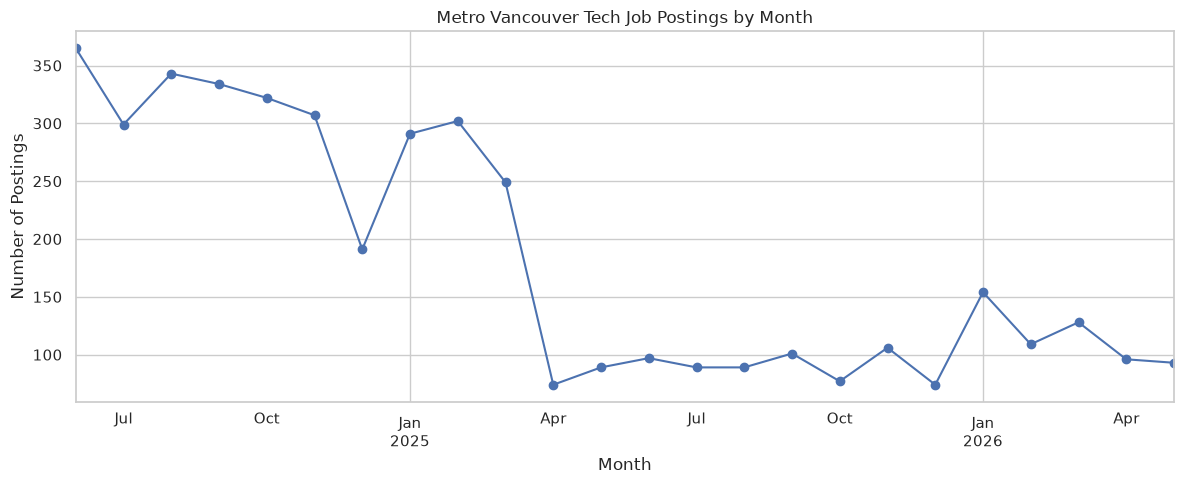

In [18]:
fig, ax = plt.subplots(figsize=(12,5))
monthly_counts.plot(ax=ax, marker="o")
ax.set_title("Metro Vancouver Tech Job Postings by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Postings")
plt.tight_layout()
plt.show()

Observation: It is possible to see an abrupt decrease in job postings in Vancouver's tech market since March 2025. Let's check if the trend is similar to the overall posting volume.

/tmp/ipykernel_22842/3892893857.py:5: DtypeWarning: Columns (0: Official Language) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv("../data/raw/combined_raw.csv")


Unparseable: 0 / 1783070


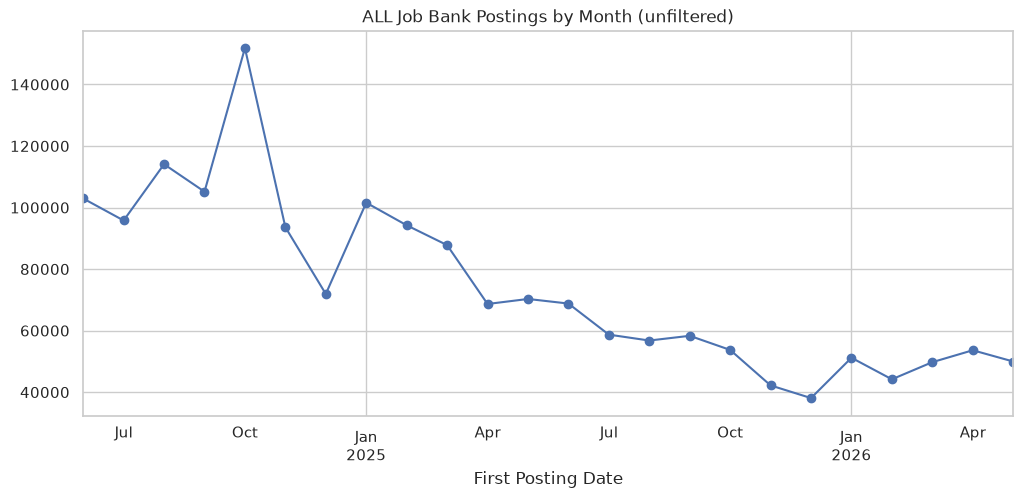

In [21]:
import sys
sys.path.insert(0, "..")
from src.data.build_dataset import parse_mixed_dates

raw = pd.read_csv("../data/raw/combined_raw.csv")
raw["First Posting Date"] = parse_mixed_dates(raw["First Posting Date"])

print("Unparseable:", raw["First Posting Date"].isna().sum(), "/", len(raw))

raw_monthly = raw.set_index("First Posting Date").resample("MS").size()

fig, ax = plt.subplots(figsize=(12, 5))
raw_monthly.plot(ax=ax, marker="o")
ax.set_title("ALL Job Bank Postings by Month (unfiltered)")
plt.show()

Observation: It is possible to see a similar decreasing trend, although there is a slightly less abrupt pattern in comparison to the tech market. Let's see how it looks if we break down the analysis by individual NOC code. This will help us understand whether it is broad-based or driven by one or two roles.

In [28]:
noc_monthly = (
    df_eda
    .set_index("First Posting Date")
    .groupby("NOC21 Code Name")
    .resample("MS")
    .size()
    .rename("count")
    .reset_index()
)

In [29]:
noc_monthly.head()

,NOC21 Code Name,First Posting Date,count
0,Business systems specialists,2024-06-01,12
1,Business systems specialists,2024-07-01,6
2,Business systems specialists,2024-08-01,12
3,Business systems specialists,2024-09-01,12
4,Business systems specialists,2024-10-01,10


In [33]:
nocs = noc_monthly["NOC21 Code Name"].unique()
palette = sns.color_palette("husl", len(nocs))

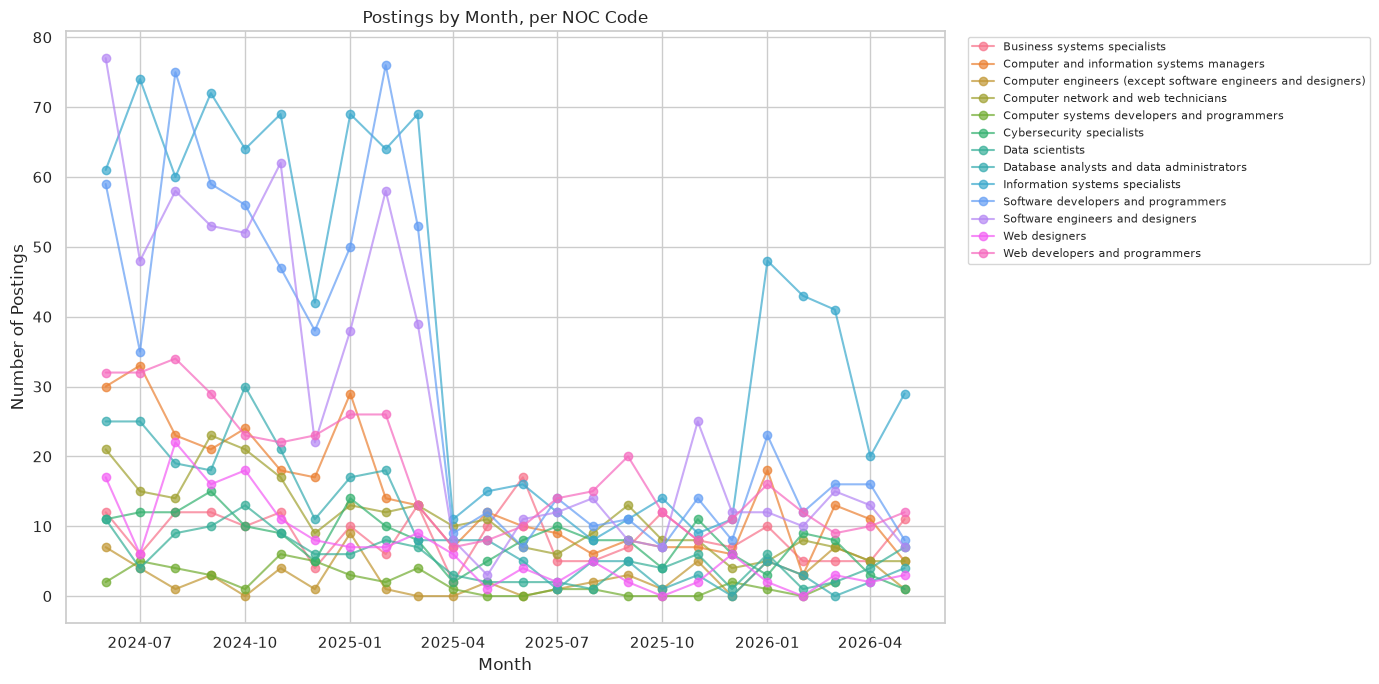

In [34]:
fig, ax = plt.subplots(figsize=(14, 7))
for color, (noc_name, group) in zip(palette, noc_monthly.groupby("NOC21 Code Name")):
    ax.plot(group["First Posting Date"], group["count"], marker="o", label=noc_name, color=color, alpha=0.7)

ax.set_title("Postings by Month, per NOC Code")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Postings")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Observation: Three NOCs in particular seem to have had the most notable dip in job postings in April 2025, compared to other NOCs: Software engineers and designers, Software developers and programmers, and Information systems specialists

Let's take a look at the counts of the month of March 2024.

In [36]:
noc_monthly[noc_monthly["First Posting Date"] == "2025-03-01"].sort_values("count", ascending=False)

,NOC21 Code Name,First Posting Date,count
199,Information systems specialists,2025-03-01,69
223,Software developers and programmers,2025-03-01,53
247,Software engineers and designers,2025-03-01,39
33,Computer and information systems managers,2025-03-01,13
9,Business systems specialists,2025-03-01,13
81,Computer network and web technicians,2025-03-01,13
295,Web developers and programmers,2025-03-01,13
271,Web designers,2025-03-01,9
127,Cybersecurity specialists,2025-03-01,8
175,Database analysts and data administrators,2025-03-01,8


Let's take a look at the count of the month of April 2024.

In [35]:
noc_monthly[noc_monthly["First Posting Date"] == "2025-04-01"].sort_values("count", ascending=False)

,NOC21 Code Name,First Posting Date,count
200,Information systems specialists,2025-04-01,11
82,Computer network and web technicians,2025-04-01,10
224,Software developers and programmers,2025-04-01,9
176,Database analysts and data administrators,2025-04-01,8
248,Software engineers and designers,2025-04-01,8
296,Web developers and programmers,2025-04-01,7
34,Computer and information systems managers,2025-04-01,7
272,Web designers,2025-04-01,6
152,Data scientists,2025-04-01,3
10,Business systems specialists,2025-04-01,2


Let's compare their typical ranking to see whether April 2025 is business-as-usual or something shifted.

In [37]:
avg_rank = (
    noc_monthly
    .assign(month_rank=noc_monthly.groupby("First Posting Date")["count"].rank(ascending=False))
    .groupby("NOC21 Code Name")["month_rank"]
    .mean()
    .sort_values()
)
print(avg_rank)

NOC21 Code Name
Information systems specialists                                  1.750000
Software developers and programmers                              2.770833
Software engineers and designers                                 3.479167
Web developers and programmers                                   3.958333
Computer and information systems managers                        5.520833
Computer network and web technicians                             6.291667
Business systems specialists                                     7.541667
Cybersecurity specialists                                        8.166667
Database analysts and data administrators                        8.229167
Web designers                                                    9.729167
Data scientists                                                 10.000000
Computer engineers (except software engineers and designers)    11.333333
Computer systems developers and programmers                     12.159091
Name: month_rank, dtyp

Observation: We see that they are consistently the NOCs with the top number of roles per month. This was not a special event for them specifically, but rather a market-wide dip that is most visible in the biggest categories.

Let's take a look at the percentaje of change from March 2025 to April 2025, to identify the NOCs that dropped the most.

In [38]:
# % change from March 2025 to April 2025, per NOC
pivot = noc_monthly.pivot(index="First Posting Date", columns="NOC21 Code Name", values="count")
pct_change = pivot.pct_change().loc["2025-04-01"].sort_values()
print(pct_change)

NOC21 Code Name
Business systems specialists                                   -0.846154
Information systems specialists                                -0.840580
Software developers and programmers                            -0.830189
Software engineers and designers                               -0.794872
Cybersecurity specialists                                      -0.750000
Computer systems developers and programmers                    -0.750000
Data scientists                                                -0.571429
Computer and information systems managers                      -0.461538
Web developers and programmers                                 -0.461538
Web designers                                                  -0.333333
Computer network and web technicians                           -0.230769
Database analysts and data administrators                       0.000000
Computer engineers (except software engineers and designers)         NaN
Name: 2025-04-01 00:00:00, dtype: f

Observation: Taking a look at percentage change, it is possible to see that the NOCs with the proportionally steepest drops in April 2025 were actually Business systems specialists (-84.61%), Information systems specialists (-84.05%), and Software developers and programmers (-83.01%).

This shows the visual dip in the top three highest-volume NOCs was partly a scale effect; the sharpest proportional declines were spread across a broader set of roles.

## 1.2 Salary Analysis

First, let's normalize the salaries to annual values.

In [ ]:
def to_annual(row, salary_col):
    val = row[salary_col]
    per = row["Salary Per"]
    if pd.isna(val) or pd.isna(per):
        return np.nan
    if per == "Year":
        return val
    elif per == "Month":
        return val * 12
    elif per == "Week":
        return val * 52
    elif per == "Bi-weekly":
        return val * 26
    elif per == "Hour":
        hours_per_week = row.get("Hours Maximum") or row.get("Hours Minimum") or 37.5
        return val * hours_per_week * 52
    else:
        return np.nan

In [ ]:
df_eda["Salary Min Annual"] = df_eda.apply(lambda r: to_annual(r, "Salary Minimum"), axis=1)
df_eda["Salary Max Annual"] = df_eda.apply(lambda r: to_annual(r, "Salary Maximum"), axis=1

In [ ]:
print(df_eda[["Salary Min Annual", "Salary Max Annual"]].describe())

In [ ]:
implausible = df_eda[
    (df_eda["Salary Max Annual"] < 15000) | (df_eda["Salary Max Annual"] > 500000)
]
print(f"Implausible rows: {len(implausible)} / {df_eda['Salary Max Annual'].notna().sum()}")